In [1]:
#Goal 1 — Supervised Classification (Churn Prediction)
#Goal 4 — SHAP Explainability & Bias Analysis
#Dataset: Telco Customer Churn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score,
                             RocCurveDisplay)

print("All libraries imported! ✅")

All libraries imported! ✅


In [3]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing values:
customerID          0
gender  

In [5]:
# Fix TotalCharges - convert string to number
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill NaN cleanly (no warning)
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Convert Churn Yes/No → 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Drop customerID - not useful for prediction
df = df.drop('customerID', axis=1)

print("TotalCharges dtype:", df['TotalCharges'].dtype)
print("Churn unique values:", df['Churn'].unique())
print("Shape:", df.shape)

TotalCharges dtype: float64
Churn unique values: [0 1]
Shape: (7043, 20)


In [6]:
le = LabelEncoder()

# Use 'str' instead of 'object' to avoid pandas warning
text_columns = df.select_dtypes(include=['str']).columns.tolist()

# Fallback in case above returns empty
if len(text_columns) == 0:
    text_columns = [col for col in df.columns 
                    if df[col].dtype == 'object' or str(df[col].dtype) == 'string']

print("Text columns to convert:", text_columns)

for col in text_columns:
    df[col] = le.fit_transform(df[col].astype(str))

print("\nAll columns converted to numbers ✅")
print(df.dtypes)

Text columns to convert: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

All columns converted to numbers ✅
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


In [7]:
print(df.describe())

            gender  SeniorCitizen      Partner   Dependents       tenure  \
count  7043.000000    7043.000000  7043.000000  7043.000000  7043.000000   
mean      0.504756       0.162147     0.483033     0.299588    32.371149   
std       0.500013       0.368612     0.499748     0.458110    24.559481   
min       0.000000       0.000000     0.000000     0.000000     0.000000   
25%       0.000000       0.000000     0.000000     0.000000     9.000000   
50%       1.000000       0.000000     0.000000     0.000000    29.000000   
75%       1.000000       0.000000     1.000000     1.000000    55.000000   
max       1.000000       1.000000     1.000000     1.000000    72.000000   

       PhoneService  MultipleLines  InternetService  OnlineSecurity  \
count   7043.000000    7043.000000      7043.000000     7043.000000   
mean       0.903166       0.940508         0.872923        0.790004   
std        0.295752       0.948554         0.737796        0.859848   
min        0.000000       0.000

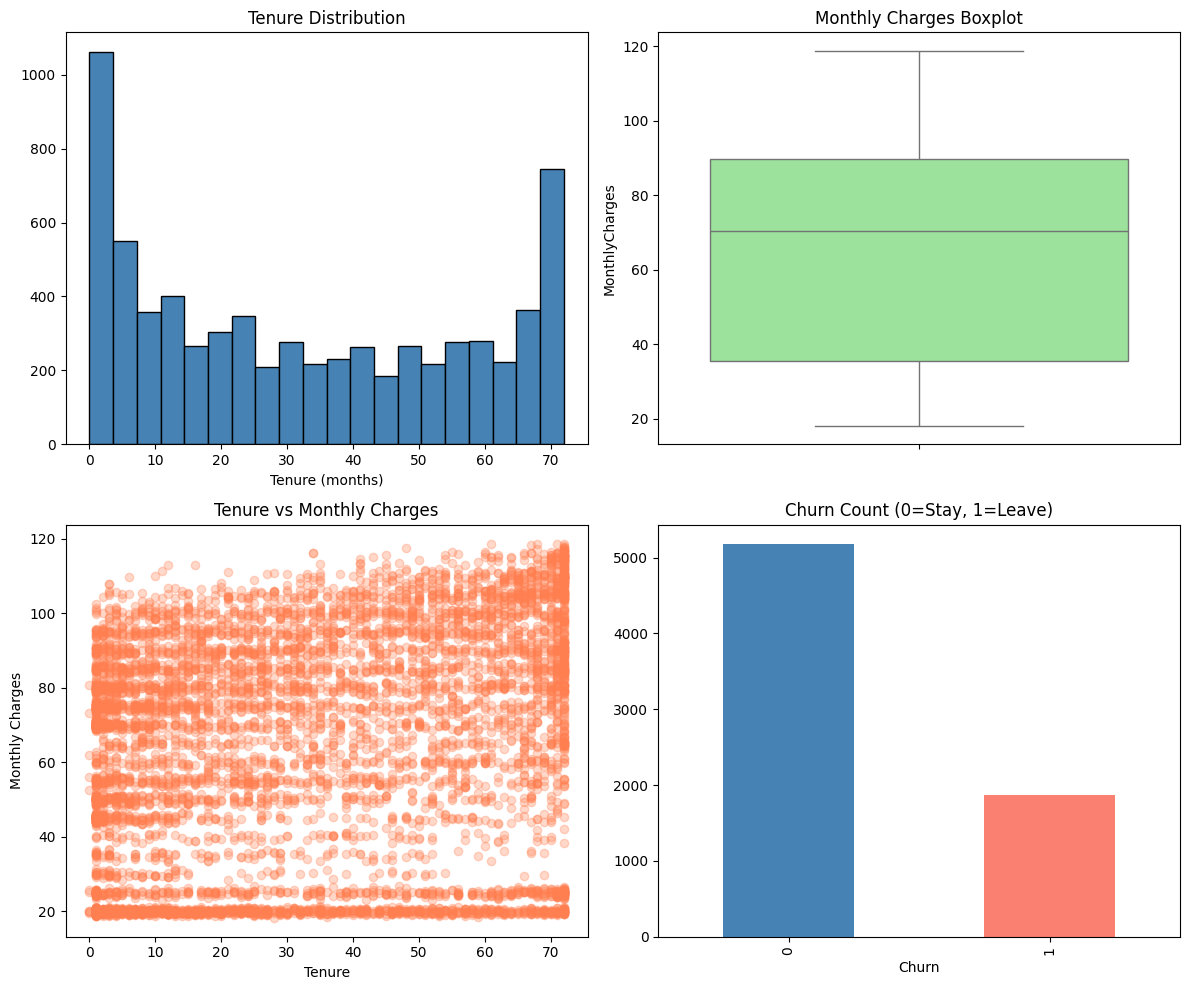

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Histogram
axes[0,0].hist(df['tenure'], bins=20, color='steelblue', edgecolor='black')
axes[0,0].set_title('Tenure Distribution')
axes[0,0].set_xlabel('Tenure (months)')

# 2. Boxplot
sns.boxplot(y=df['MonthlyCharges'], ax=axes[0,1], color='lightgreen')
axes[0,1].set_title('Monthly Charges Boxplot')

# 3. Scatter
axes[1,0].scatter(df['tenure'], df['MonthlyCharges'], alpha=0.3, color='coral')
axes[1,0].set_title('Tenure vs Monthly Charges')
axes[1,0].set_xlabel('Tenure')
axes[1,0].set_ylabel('Monthly Charges')

# 4. Bar
df['Churn'].value_counts().plot(kind='bar', ax=axes[1,1], 
                                 color=['steelblue','salmon'])
axes[1,1].set_title('Churn Count (0=Stay, 1=Leave)')
axes[1,1].set_xlabel('Churn')

plt.tight_layout()
plt.show()

In [9]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (5634, 19)
Testing size: (1409, 19)


In [10]:
# Scale data for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
lr = LogisticRegression(max_iter=2000, solver='lbfgs')
lr.fit(X_train_scaled, y_train)
print("Logistic Regression trained! ✅")

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("Random Forest trained! ✅")

Logistic Regression trained! ✅
Random Forest trained! ✅


In [11]:
lr_pred = lr.predict(X_test_scaled)
rf_pred = rf.predict(X_test)

models = {'Logistic Regression': lr_pred, 'Random Forest': rf_pred}

for name, pred in models.items():
    print(f"\n--- {name} ---")
    print(f"Accuracy  : {accuracy_score(y_test, pred):.4f}")
    print(f"Precision : {precision_score(y_test, pred):.4f}")
    print(f"Recall    : {recall_score(y_test, pred):.4f}")
    print(f"F1 Score  : {f1_score(y_test, pred):.4f}")
    print(f"ROC-AUC   : {roc_auc_score(y_test, pred):.4f}")


--- Logistic Regression ---
Accuracy  : 0.8155
Precision : 0.6771
Recall    : 0.5791
F1 Score  : 0.6243
ROC-AUC   : 0.7398

--- Random Forest ---
Accuracy  : 0.7956
Precision : 0.6592
Recall    : 0.4718
F1 Score  : 0.5500
ROC-AUC   : 0.6920


In [12]:
lr_cv = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='f1')
rf_cv = cross_val_score(rf, X_train, y_train, cv=5, scoring='f1')

print("Logistic Regression CV F1 scores:", lr_cv.round(4))
print("LR Average F1:", lr_cv.mean().round(4))

print("\nRandom Forest CV F1 scores:", rf_cv.round(4))
print("RF Average F1:", rf_cv.mean().round(4))

Logistic Regression CV F1 scores: [0.6341 0.5955 0.5647 0.5729 0.5704]
LR Average F1: 0.5875

Random Forest CV F1 scores: [0.5948 0.5543 0.4942 0.5388 0.5315]
RF Average F1: 0.5427


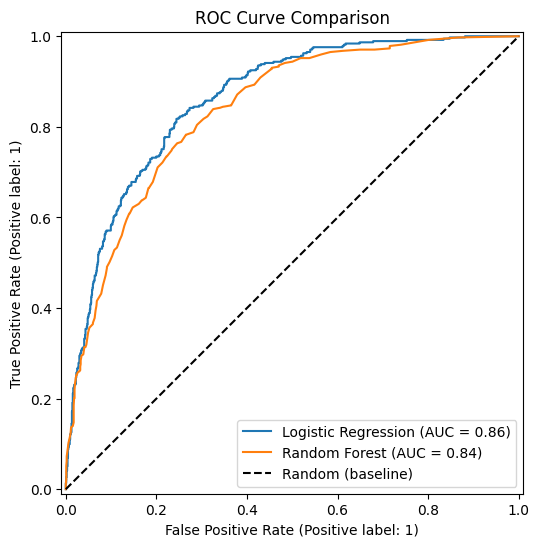

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_estimator(lr, X_test_scaled, y_test, 
                                ax=ax, name='Logistic Regression')
RocCurveDisplay.from_estimator(rf, X_test, y_test, 
                                ax=ax, name='Random Forest')

ax.plot([0,1], [0,1], 'k--', label='Random (baseline)')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.show()

In [14]:
#Goal 4

In [15]:
import subprocess
subprocess.run(['pip', 'install', 'shap'], capture_output=True)
print("SHAP installed! ✅")


SHAP installed! ✅


In [16]:
import shap
print("SHAP version:", shap.__version__)


SHAP version: 0.52.0


In [17]:
# Create SHAP explainer for Random Forest
explainer = shap.TreeExplainer(rf)

# Calculate SHAP values for test set
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated! ✅")
print("Shape of SHAP values:", shap_values.shape)

SHAP values calculated! ✅
Shape of SHAP values: (1409, 19, 2)


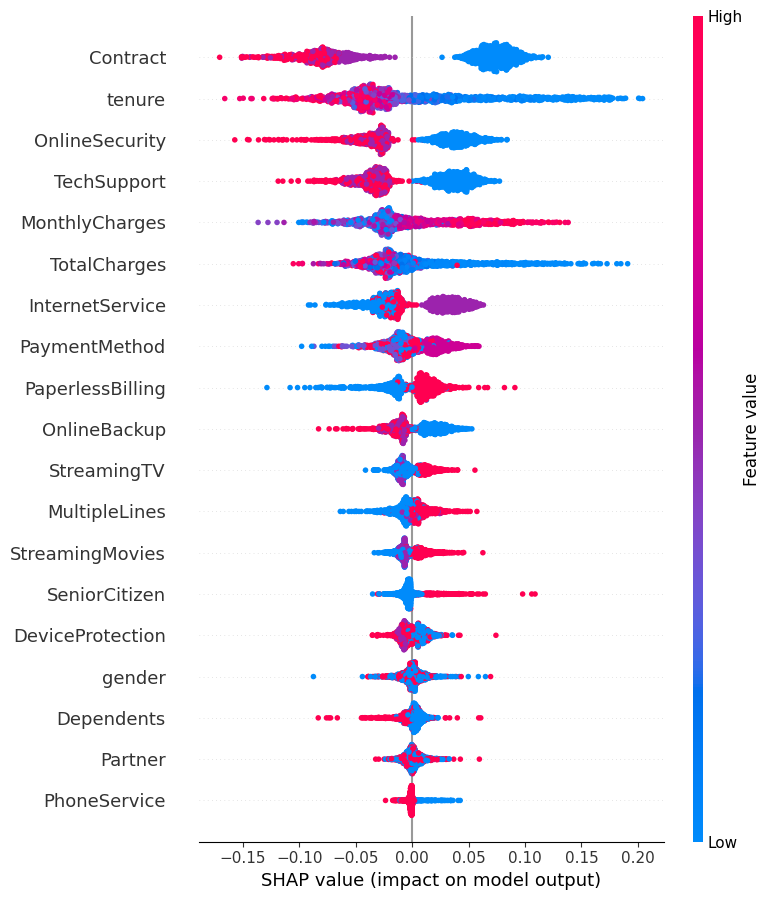

In [18]:
# We use [:,:,1] because index 1 = Churn class
shap.summary_plot(shap_values[:,:,1], X_test, 
                  feature_names=X_test.columns.tolist())

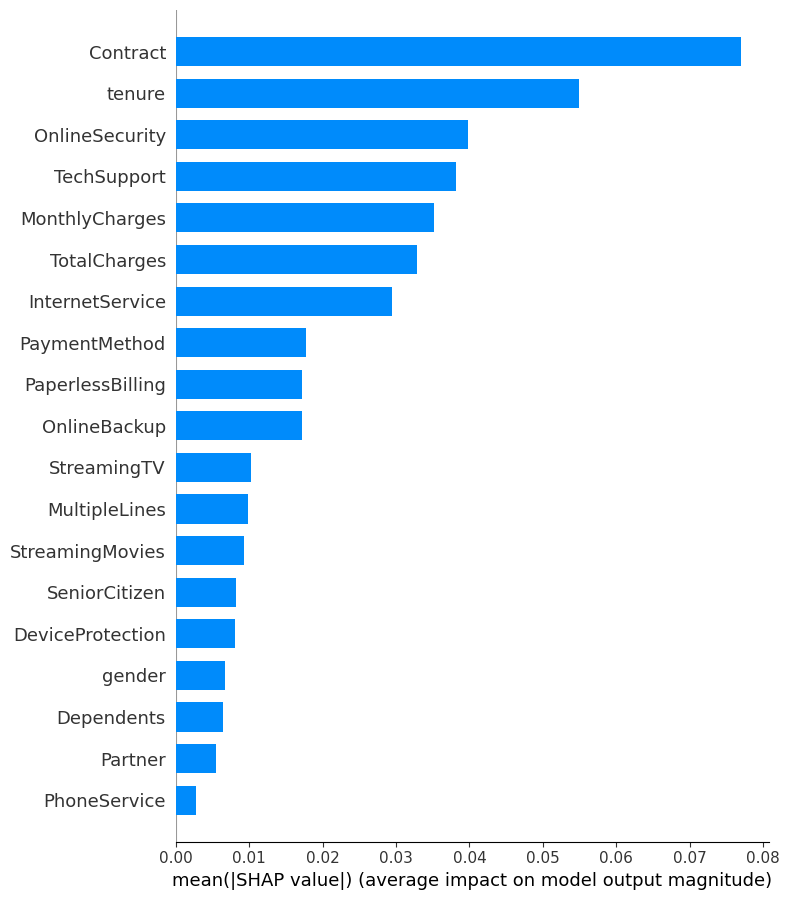

In [19]:
shap.summary_plot(shap_values[:,:,1], X_test,
                  feature_names=X_test.columns.tolist(),
                  plot_type='bar')

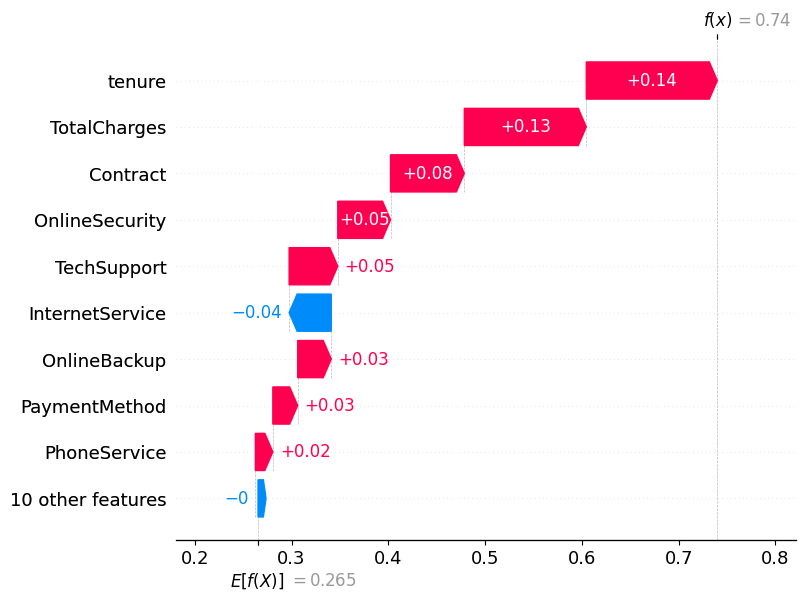

In [20]:
# Explain prediction for customer number 0 (first test customer)
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[0,:,1],
        base_values=explainer.expected_value[1],
        feature_names=X_test.columns.tolist()
    )
)


In [21]:
# Add predictions to test set for bias analysis
X_test_copy = X_test.copy()
X_test_copy['Actual'] = y_test.values
X_test_copy['Predicted'] = rf.predict(X_test)

# Check accuracy for Male vs Female
print("=== Gender Bias Check ===")
for gender_val, label in [(0, 'Female'), (1, 'Male')]:
    subset = X_test_copy[X_test_copy['gender'] == gender_val]
    acc = accuracy_score(subset['Actual'], subset['Predicted'])
    print(f"{label}: Accuracy = {acc:.4f} ({len(subset)} customers)")

# Check accuracy for Senior vs Non-Senior
print("\n=== Senior Citizen Bias Check ===")
for senior_val, label in [(0, 'Non-Senior'), (1, 'Senior')]:
    subset = X_test_copy[X_test_copy['SeniorCitizen'] == senior_val]
    acc = accuracy_score(subset['Actual'], subset['Predicted'])
    print(f"{label}: Accuracy = {acc:.4f} ({len(subset)} customers)")

=== Gender Bias Check ===
Female: Accuracy = 0.7827 (741 customers)
Male: Accuracy = 0.8099 (668 customers)

=== Senior Citizen Bias Check ===
Non-Senior: Accuracy = 0.8090 (1173 customers)
Senior: Accuracy = 0.7288 (236 customers)


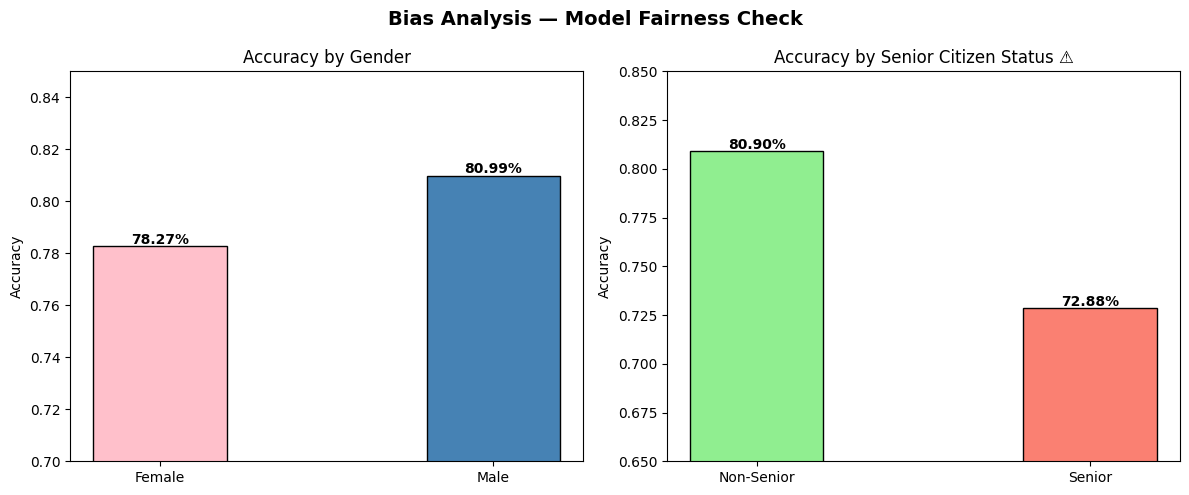

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gender bias plot
categories = ['Female', 'Male']
accuracies = [0.7827, 0.8099]
axes[0].bar(categories, accuracies, color=['pink', 'steelblue'], 
            edgecolor='black', width=0.4)
axes[0].set_title('Accuracy by Gender')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.70, 0.85)
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.001, f'{v:.2%}', ha='center', fontweight='bold')

# Senior citizen bias plot
categories2 = ['Non-Senior', 'Senior']
accuracies2 = [0.8090, 0.7288]
axes[1].bar(categories2, accuracies2, color=['lightgreen', 'salmon'], 
            edgecolor='black', width=0.4)
axes[1].set_title('Accuracy by Senior Citizen Status ⚠️')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.65, 0.85)
for i, v in enumerate(accuracies2):
    axes[1].text(i, v + 0.001, f'{v:.2%}', ha='center', fontweight='bold')

plt.suptitle('Bias Analysis — Model Fairness Check', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

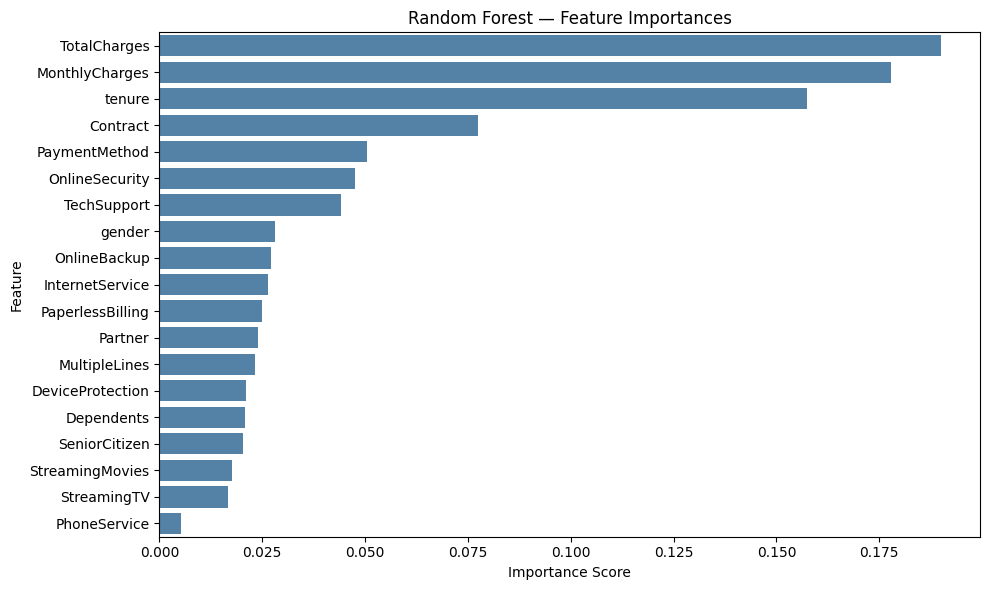

         Feature  Importance
    TotalCharges    0.189992
  MonthlyCharges    0.177867
          tenure    0.157428
        Contract    0.077357
   PaymentMethod    0.050379
  OnlineSecurity    0.047432
     TechSupport    0.044190
          gender    0.028117
    OnlineBackup    0.027067
 InternetService    0.026444
PaperlessBilling    0.024917
         Partner    0.023864
   MultipleLines    0.023131
DeviceProtection    0.021012
      Dependents    0.020709
   SeniorCitizen    0.020354
 StreamingMovies    0.017737
     StreamingTV    0.016749
    PhoneService    0.005254


In [23]:
# Get feature importances from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X_test.columns.tolist(),
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', 
            data=feature_importance, color='steelblue')
plt.title('Random Forest — Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(feature_importance.to_string(index=False))

In [24]:
import pickle

# Save the model and scaler to files
with open('model.pkl', 'wb') as f:
    pickle.dump(lr, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model saved! ✅")
print("Scaler saved! ✅")

Model saved! ✅
Scaler saved! ✅
